<a href="https://colab.research.google.com/github/thaya-06/gilliespie-algorithm/blob/gillespie-algorithm-types/intership_summer_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

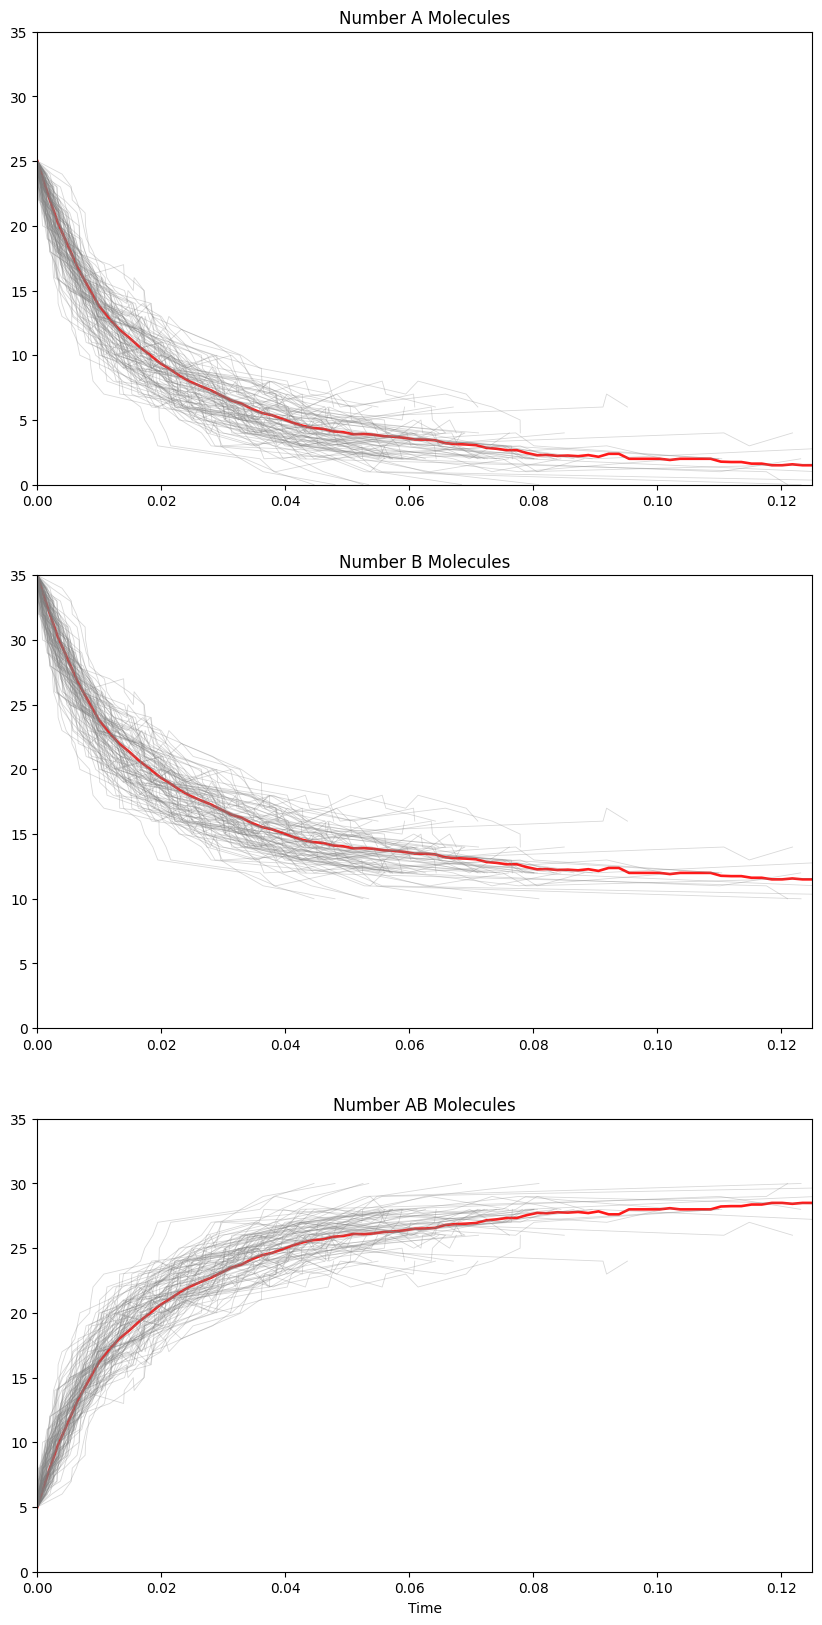

In [4]:
# An implenetation of the Gillespie algorithm
# applied to a pair of reactions:
# A + B -> AB
# AB -> A + B

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Fix random seed for repeatability
np.random.seed(123)

###### Fix model parameters ######
N_A0 = 25     # Initial number of A molecules
N_B0 = 35     # Initial number of B molecules
N_AB0 = 5     # Initial number of AB molecules

rf = 2        # Forward reaction rate
rb = 1        # Backwards reaction rate

steps = 25    # Number of reactions per trajectory
cycles = 100  # Number of trajectories iterated over

# Set up holder arrays
T = np.zeros((cycles, steps+1))
N_A = np.zeros((cycles, steps+1))
N_B = np.zeros((cycles, steps+1))
N_AB = np.zeros((cycles, steps+1))

# Store initial conditions
N_A[:,0] = N_A0
N_B[:,0] = N_B0
N_AB[:,0] = N_AB0

###### Main Code Loop ######
for i in range(cycles):
    for j in range(steps):
        # Calculate updated overall reaction rate
        R = rf * N_A[i,j] * N_B[i,j] + rb * N_AB[i,j]

        # Calculate time to next reaction
        u1 = np.random.random()
        tau = 1/R * np.log(1/u1)

        # Store reaction time
        T[i, j+1] = T[i,j] + tau

        # Select which reaction to occur
        Rf = rf * N_A[i,j] * N_B[i,j] / R
        u2 = np.random.random()

        # Update populations
        if u2 < Rf:
            N_A[i,j+1] = N_A[i,j] - 1
            N_B[i,j+1] = N_B[i,j] - 1
            N_AB[i,j+1] = N_AB[i,j] + 1
        else:
            N_A[i,j+1] = N_A[i,j] + 1
            N_B[i,j+1] = N_B[i,j] + 1
            N_AB[i,j+1] = N_AB[i,j] - 1

# Calculate an average trajectory plot
ave_steps = 100
T_max = T.max()

# Set up average arrays
T_ave = np.linspace(0,T_max,ave_steps+1)
N_A_ave = np.zeros(ave_steps+1)
N_B_ave = np.zeros(ave_steps+1)
N_AB_ave = np.zeros(ave_steps+1)

N_A_ave[0] = N_A0
N_B_ave[0] = N_B0
N_AB_ave[0] = N_AB0

# Pass over average array entries
for i in range(1, ave_steps+1):
    tmax = T_ave[i]
    A_sum = 0
    B_sum = 0
    AB_sum = 0
    t_count = 0

    # Pass over each trajectory and step therein
    for j in range(cycles):
        for k in range(steps):
            if T[j,k] <= tmax and T[j,k+1] > tmax:
                t_count += 1
                A_sum += N_A[j,k]
                B_sum += N_B[j,k]
                AB_sum += N_AB[j,k]

    # Caclulate average - taking care if no samples observed
    if t_count == 0:
        N_A_ave[i] = N_A_ave[i-1]
        N_B_ave[i] = N_B_ave[i-1]
        N_AB_ave[i] = N_AB_ave[i-1]
    else:
        N_A_ave[i] = A_sum / t_count
        N_B_ave[i] = B_sum / t_count
        N_AB_ave[i] = AB_sum / t_count


###### Plot Trajectories ######
fig, axs = plt.subplots(3, 1, figsize=(10,20))

# Plot average trajectories
axs[0].plot(T_ave, N_A_ave, marker='', color='red', linewidth=1.9, alpha=0.9)
axs[0].set_title('Number A Molecules')
axs[0].set_ylim((0,35))
axs[0].set_xlim((0,0.125))
axs[1].plot(T_ave, N_B_ave, marker='', color='red', linewidth=1.9, alpha=0.9)
axs[1].set_title('Number B Molecules')
axs[1].set_ylim((0,35))
axs[1].set_xlim((0,0.125))
axs[2].plot(T_ave, N_AB_ave, marker='', color='red', linewidth=1.9, alpha=0.9)
axs[2].set_title('Number AB Molecules')
axs[2].set_xlabel("Time")
axs[2].set_ylim((0,35))
axs[2].set_xlim((0,0.125))

# Plot each simulated trajectory
for i in range(cycles):
    axs[0].plot(T[i,:], N_A[i,:], marker='', color='grey', linewidth=0.6, alpha=0.3)
    axs[1].plot(T[i,:], N_B[i,:], marker='', color='grey', linewidth=0.6, alpha=0.3)
    axs[2].plot(T[i,:], N_AB[i,:], marker='', color='grey', linewidth=0.6, alpha=0.3)

plt.show()


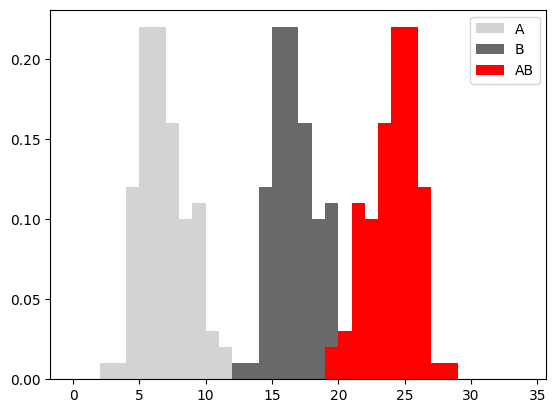

In [12]:
import numpy as np
import matplotlib.pyplot as plt

time = 0.025
N_A_time = np.zeros(cycles)
N_B_time = np.zeros(cycles)
N_AB_time = np.zeros(cycles)

for i in range(cycles):
    for j in range(1, steps):
        if T[j] >= time and T[j-1] < time:
            N_A_time[i] = N_A[i,j]
            N_B_time[i] = N_B[i,j]
            N_AB_time[i] = N_AB[i,j]
    # If trajectory doesn't span far enough take latest observation
    if T[steps] < time:
        N_A_time[i] = N_A[i, steps]
        N_B_time[i] = N_B[i, steps]
        N_AB_time[i] = N_AB[i, steps]

plt.hist(N_A_time, density=True, bins=np.arange(35), label="A", color='lightgrey')
plt.hist(N_B_time, density=True, bins=np.arange(35), label="B", color='dimgrey')
plt.hist(N_AB_time, density=True, bins=np.arange(35), label="AB", color='red')
plt.legend()
plt.show()

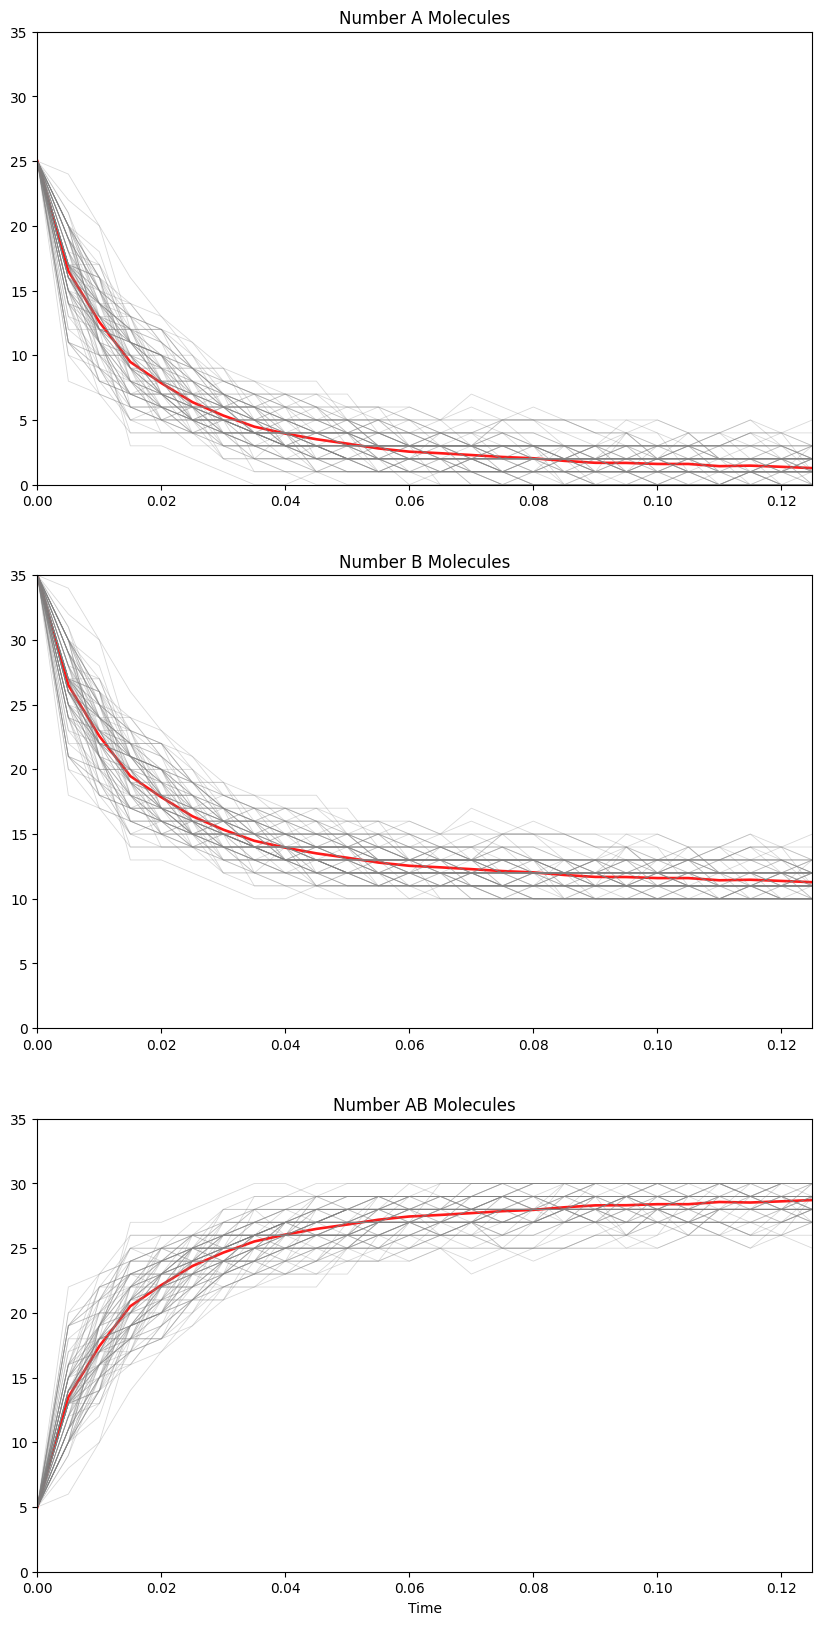

In [15]:
# An implenetation of the Gillespie algorithm
# with tau leaping
# Applied to a pair of reactions:
# A + B -> AB
# AB -> A + B

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
%matplotlib inline

# Fix random seed for repeatability
np.random.seed(123)

###### Fix model parameters ######
N_A0 = 25     # Initial number of A molecules
N_B0 = 35     # Initial number of B molecules
N_AB0 = 5     # Initial number of AB molecules

rf = 2        # Forward reaction rate
rb = 1        # Backwards reaction rate

leap = 0.005 # Size of leaping steps

steps = 25    # Number of leaps per trajectory
cycles = 100  # Number of trajectories iterated over

# Set up holder arrays
T = np.arange(steps+1)*leap
N_A = np.zeros((cycles, steps+1))
N_B = np.zeros((cycles, steps+1))
N_AB = np.zeros((cycles, steps+1))

# Store initial conditions
N_A[:,0] = N_A0
N_B[:,0] = N_B0
N_AB[:,0] = N_AB0

###### Main Code Loop ######
for i in range(cycles):
    for j in range(steps):
        # Calculate updated reaction rates
        Rf = rf * N_A[i,j] * N_B[i,j]
        Rb = rb * N_AB[i,j]

        # Calculate number of reactions by type
        uf = np.random.random()
        ub = np.random.random()

        Nf = poisson.ppf(uf, Rf*leap)
        Nb = poisson.ppf(ub, Rb*leap)

        # Apply limits to prevent negative population
        Limitf = min(N_A[i,j], N_B[i,j])
        Limitb = N_AB[i,j]

        Nf = min(Nf, Limitf)
        Nb = min(Nb, Limitb)

        # Update populations
        N_A[i,j+1] = N_A[i,j] + Nb - Nf
        N_B[i,j+1] = N_B[i,j] + Nb - Nf
        N_AB[i,j+1] = N_AB[i,j] + Nf - Nb

# Calculate average arrays
N_A_ave = N_A.mean(axis=0)
N_B_ave = N_B.mean(axis=0)
N_AB_ave = N_AB.mean(axis=0)

###### Plot Trajectories ######
fig, axs = plt.subplots(3, 1, figsize=(10,20))

# Plot average trajectories
axs[0].plot(T, N_A_ave, marker='', color='red', linewidth=1.9, alpha=0.9)
axs[0].set_title('Number A Molecules')
axs[0].set_ylim((0,35))
axs[0].set_xlim((0,0.125))
axs[1].plot(T, N_B_ave, marker='', color='red', linewidth=1.9, alpha=0.9)
axs[1].set_title('Number B Molecules')
axs[1].set_ylim((0,35))
axs[1].set_xlim((0,0.125))
axs[2].plot(T, N_AB_ave, marker='', color='red', linewidth=1.9, alpha=0.9)
axs[2].set_title('Number AB Molecules')
axs[2].set_xlabel("Time")
axs[2].set_ylim((0,35))
axs[2].set_xlim((0,0.125))

# Plot each simulated trajectory
for i in range(cycles):
    axs[0].plot(T[:], N_A[i,:], marker='', color='grey', linewidth=0.6, alpha=0.3)
    axs[1].plot(T[:], N_B[i,:], marker='', color='grey', linewidth=0.6, alpha=0.3)
    axs[2].plot(T[:], N_AB[i,:], marker='', color='grey', linewidth=0.6, alpha=0.3)

plt.show()

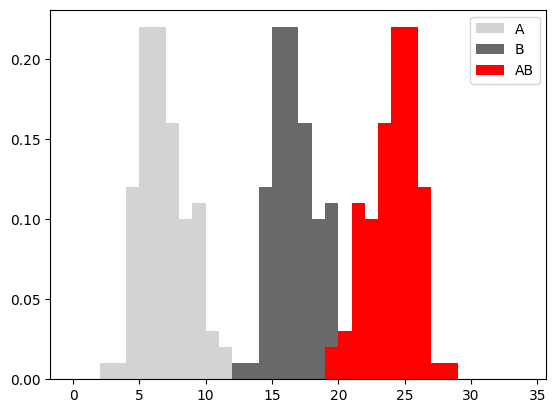

In [11]:
time = 0.025
N_A_time = np.zeros(cycles)
N_B_time = np.zeros(cycles)
N_AB_time = np.zeros(cycles)

for i in range(cycles):
    for j in range(1, steps):
        if T[j] >= time and T[j-1] < time:
            N_A_time[i] = N_A[i,j]
            N_B_time[i] = N_B[i,j]
            N_AB_time[i] = N_AB[i,j]
    # If trajectory doesn't span far enough take latest observation
    if T[steps] < time:
        N_A_time[i] = N_A[i, steps]
        N_B_time[i] = N_B[i, steps]
        N_AB_time[i] = N_AB[i, steps]

plt.hist(N_A_time, density=True, bins=np.arange(35), label="A", color='lightgrey')
plt.hist(N_B_time, density=True, bins=np.arange(35), label="B", color='dimgrey')
plt.hist(N_AB_time, density=True, bins=np.arange(35), label="AB", color='red')
plt.legend()
plt.show()

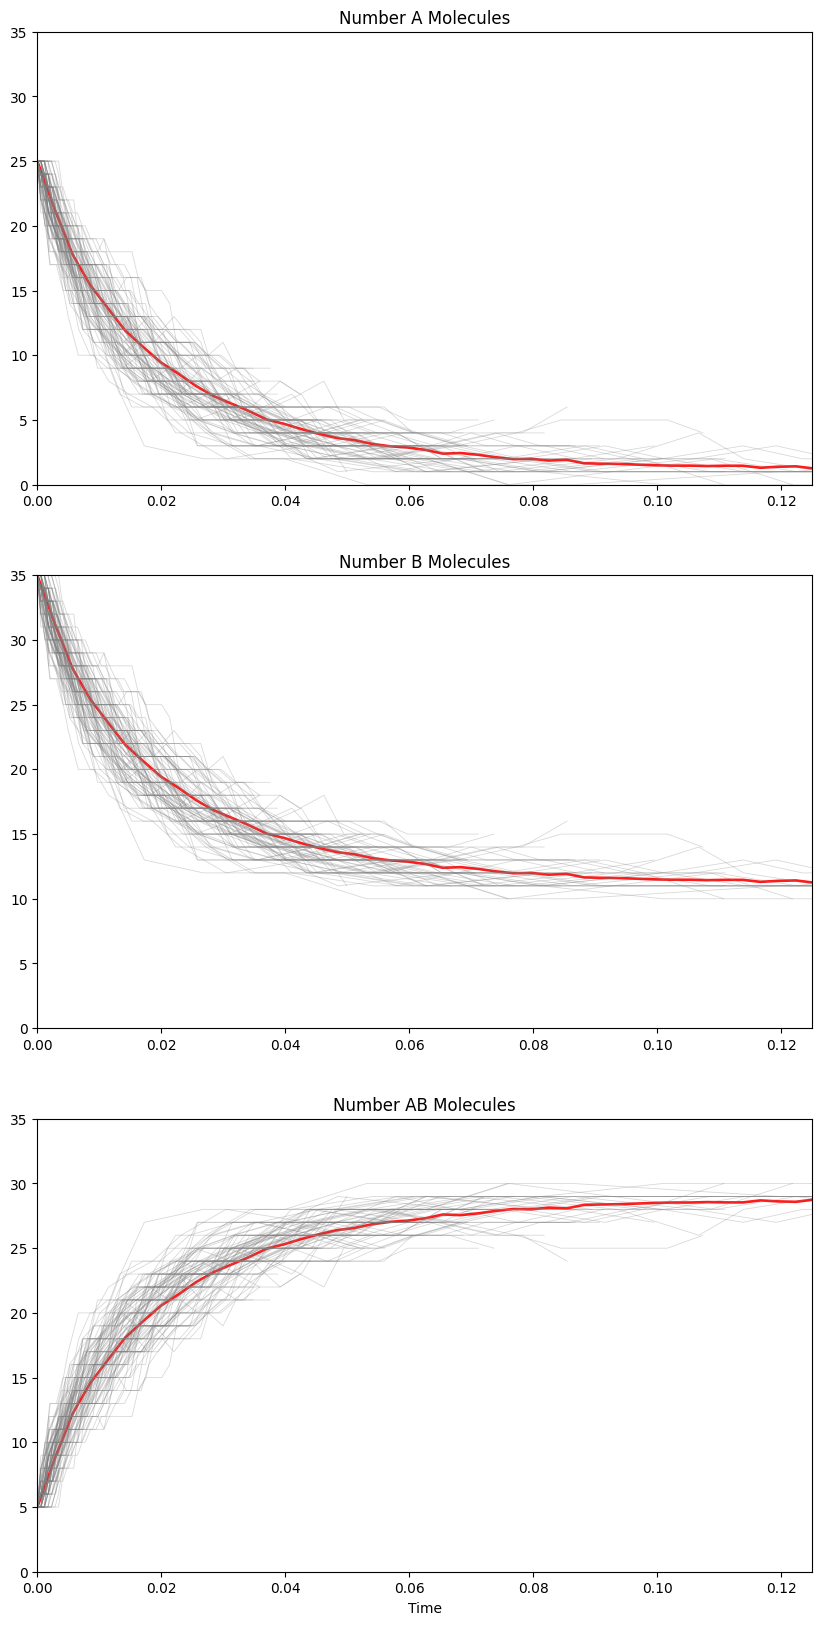

In [16]:
# An implenetation of the Gillespie algorithm
# With adaptive tau-leaping
# Applied to a pair of reactions:
# A + B -> AB
# AB -> A + B

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
%matplotlib inline

# Fix random seed for repeatability
np.random.seed(123)

###### Fix model parameters ######
N_A0 = 25     # Initial number of A molecules
N_B0 = 35     # Initial number of B molecules
N_AB0 = 5     # Initial number of AB molecules

rf = 2        # Forward reaction rate
rb = 1        # Backwards reaction rate

eps = 0.03    # Epsilon adaptive rate

steps = 25    # Number of reactions per trajectory
cycles = 100  # Number of trajectories iterated over

# Set up holder arrays
T = np.zeros((cycles, steps+1))
N_A = np.zeros((cycles, steps+1))
N_B = np.zeros((cycles, steps+1))
N_AB = np.zeros((cycles, steps+1))

# Store initial conditions
N_A[:,0] = N_A0
N_B[:,0] = N_B0
N_AB[:,0] = N_AB0

###### Main Code Loop ######
for i in range(cycles):
    for j in range(steps):
        # Calculate updated reaction rates
        Rf = rf * N_A[i,j] * N_B[i,j]
        Rb = rb * N_AB[i,j]

        # Calculate auxiliary variables
        mu_A = Rf - Rb
        mu_B = Rf - Rb
        mu_AB = Rb - Rf

        sig2_A = Rf + Rb
        sig2_B = Rf + Rb
        sig2_AB = Rf + Rb

        # Select highest order reactions
        g_A = Rf
        g_B = Rf
        g_AB = Rb

        # Caclulate internal maxima - taking care of divide by zero
        if g_A == 0:
            max_A = 1
        else:
            max_A = max(eps*N_A[i,j]/g_A,1)

        if g_B == 0:
            max_B = 1
        else:
            max_B = max(eps*N_B[i,j]/g_B, 1)

        if g_AB == 0:
            max_AB = 1
        else:
            max_AB = max(eps*N_AB[i,j]/g_AB, 1)

        # Calculate minima for each component
        min_A = min(max_A / abs(mu_A), max_A**2 / sig2_A)
        min_B = min(max_B / abs(mu_B), max_B**2 / sig2_B)
        min_AB = min(max_AB / abs(mu_AB), max_AB**2 / sig2_AB)

        # Select tau leap size
        leap = min(min_A, min_B, min_AB)

        # Calculate number of reactions by type
        uf = np.random.random()
        ub = np.random.random()

        Nf = poisson.ppf(uf, Rf*leap)
        Nb = poisson.ppf(ub, Rb*leap)

        # Apply limits to prevent negative population
        Limitf = min(N_A[i,j], N_B[i,j])
        Limitb = N_AB[i,j]

        Nf = min(Nf, Limitf)
        Nb = min(Nb, Limitb)

        # Update populations and times
        N_A[i,j+1] = N_A[i,j] + Nb - Nf
        N_B[i,j+1] = N_B[i,j] + Nb - Nf
        N_AB[i,j+1] = N_AB[i,j] + Nf - Nb
        T[i,j+1] = T[i,j] + leap

# Calculate an average trajectory plot
ave_steps = 100
T_max = T.max()

# Set up average array holders
T_ave = np.linspace(0,T_max,ave_steps+1)
N_A_ave = np.zeros(ave_steps+1)
N_B_ave = np.zeros(ave_steps+1)
N_AB_ave = np.zeros(ave_steps+1)

N_A_ave[0] = N_A0
N_B_ave[0] = N_B0
N_AB_ave[0] = N_AB0

# Pass over average array entries
for i in range(1, ave_steps+1):
    tmax = T_ave[i]
    A_sum = 0
    B_sum = 0
    AB_sum = 0
    t_count = 0

    # Pass over each trajectory and step therein
    for j in range(cycles):
        for k in range(steps):
            if T[j,k] <= tmax and T[j,k+1] > tmax:
                t_count += 1
                A_sum += N_A[j,k]
                B_sum += N_B[j,k]
                AB_sum += N_AB[j,k]

    # Caclulate average - taking care if no samples observed
    if t_count == 0:
        N_A_ave[i] = N_A_ave[i-1]
        N_B_ave[i] = N_B_ave[i-1]
        N_AB_ave[i] = N_AB_ave[i-1]
    else:
        N_A_ave[i] = A_sum / t_count
        N_B_ave[i] = B_sum / t_count
        N_AB_ave[i] = AB_sum / t_count


###### Plot Trajectories ######
fig, axs = plt.subplots(3, 1, figsize=(10,20))

axs[0].plot(T_ave, N_A_ave, marker='', color='red', linewidth=1.9, alpha=0.9)
axs[0].set_title('Number A Molecules')
axs[0].set_ylim((0,35))
axs[0].set_xlim((0,0.125))
axs[1].plot(T_ave, N_B_ave, marker='', color='red', linewidth=1.9, alpha=0.9)
axs[1].set_title('Number B Molecules')
axs[1].set_ylim((0,35))
axs[1].set_xlim((0,0.125))
axs[2].plot(T_ave, N_AB_ave, marker='', color='red', linewidth=1.9, alpha=0.9)
axs[2].set_title('Number AB Molecules')
axs[2].set_xlabel("Time")
axs[2].set_ylim((0,35))
axs[2].set_xlim((0,0.125))

for i in range(cycles):
    axs[0].plot(T[i,:], N_A[i,:], marker='', color='grey', linewidth=0.6, alpha=0.3)
    axs[1].plot(T[i,:], N_B[i,:], marker='', color='grey', linewidth=0.6, alpha=0.3)
    axs[2].plot(T[i,:], N_AB[i,:], marker='', color='grey', linewidth=0.6, alpha=0.3)

plt.show()

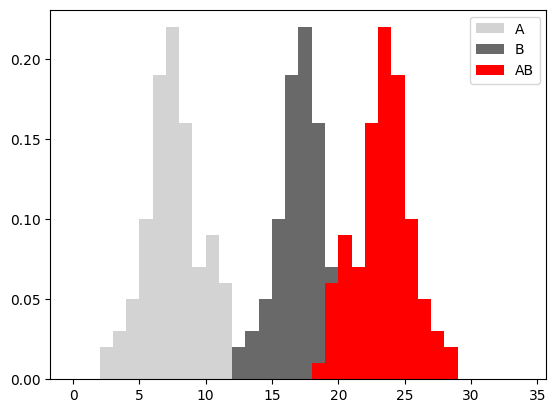

In [17]:
time = 0.025
N_A_time = np.zeros(cycles)
N_B_time = np.zeros(cycles)
N_AB_time = np.zeros(cycles)

for i in range(cycles):
    for j in range(1, steps+1):
        if T[i,j] >= time and T[i,j-1] < time:
            N_A_time[i] = N_A[i,j]
            N_B_time[i] = N_B[i,j]
            N_AB_time[i] = N_AB[i,j]
    if T[i, steps] < time:
        N_A_time[i] = N_A[i, steps]
        N_B_time[i] = N_B[i, steps]
        N_AB_time[i] = N_AB[i, steps]

plt.hist(N_A_time, density=True, bins=np.arange(35), label="A", color='lightgrey')
plt.hist(N_B_time, density=True, bins=np.arange(35), label="B", color='dimgrey')
plt.hist(N_AB_time, density=True, bins=np.arange(35), label="AB", color='red')
plt.legend()
plt.show()